# Bearing fault diagnosis on CWRU: a leakage audit and an industrial evaluation

[README](../README.md) · [full pipeline, step by step](bearing_audit_full_pipeline.ipynb) · [walkthrough](../docs/walkthrough.md)

This notebook goes through the project in about ten minutes. Every table and figure in it is either read
from `reports/results/` (written by `make all`) or computed live from the recordings; none of them is typed
in by hand.

### The short version

- The CWRU bearing dataset is known for near-perfect accuracy. Most of that comes from leakage: the same
  model scores almost perfectly when the test windows come from recordings it has already seen, and much
  lower on bearings it has never seen.
- Before training anything, I fixed a ship gate for unseen bearings. No model passes it, and that is the
  result I report.
- The industrial evaluation then judges every system the way a plant would: one decision per recording,
  false alarms first, and the option to answer "undiagnosed". Detection is solved on this data. Diagnosis
  on unseen bearings is not.

To run it yourself (Python 3.11 or 3.12):

```bash
pip install -r requirements-lock.txt && pip install -e ".[notebook]"
bearing-audit fetch      # the 56 recordings, each checked against its SHA-256 (~190 MB)
jupyter lab notebooks/bearing_audit_presentation.ipynb
```

Sections 3 and 7 need the recordings. The rest only reads the committed results, so it runs without them.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from bearing_audit import SKF_6205, BearingMonitor, __version__, bearing, catalog, config, dsp, loader, plots

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS, FIGURES, DATA = ROOT / "reports/results", ROOT / "reports/figures", ROOT / "data/raw"
HAVE_DATA = DATA.is_dir() and any(DATA.glob("*.mat"))
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 90, "axes.titleweight": "bold"})  # the rest of the style comes with `plots`


# read a committed result file
def result(name):
    path = RESULTS / name
    return json.loads(path.read_text()) if path.suffix == ".json" else pd.read_csv(path)


# show a committed figure
def figure(name, width=820):
    display(Image(filename=FIGURES / name, width=width))


print(f"bearing_audit {__version__} | recordings available: {HAVE_DATA}")

bearing_audit 1.0.0 | recordings available: True


### The headline: one model, three ways of testing it

Mean macro-F1 across folds (4 classes: healthy, inner race, ball, outer race). The three
protocols are explained in section 4.

In [2]:
audit = result("audit_summary.csv").query("task == 'type4'")
gate = result("gate.json")
headline = audit.pivot(index="model", columns="protocol", values="mean_macro_f1").rename(columns=plots.PROTO_NAME)
headline.index = headline.index.map(plots.MODEL_NAME)
print(f"Pre-registered ship gate: {gate['criterion']}.  Ship: {gate['ship']}")
headline

Pre-registered ship gate: protocol C, 4-class: mean macro-F1 >= 0.9 and every class recall >= 0.8.  Ship: False


protocol,A random windows,B unseen load,C unseen bearing
model,,,
random forest (all features),1.00,0.994,0.732
"physics rule, fixed band",0.65,0.645,0.603
"physics rule, kurtosis band",0.58,0.573,0.603


## 1. The physics: where a fault frequency comes from

A defect on a bearing race is struck every time a ball rolls over it. How often that happens depends
only on the bearing's geometry and the shaft speed. That gives each fault a frequency of its own:
BPFI (inner race), BPFO (outer race) and 2×BSF (ball). The table recomputes them from the
SKF 6205's dimensions and checks them against the values CWRU publishes.

In [3]:
kin = pd.DataFrame(
    {"computed (x shaft speed)": pd.Series(SKF_6205.multiples()), "CWRU published": pd.Series(bearing.CWRU_PUBLISHED)}
).dropna()
kin["difference %"] = (100 * (kin.iloc[:, 0] / kin.iloc[:, 1] - 1)).round(3)
kin["Hz at 1797 rpm"] = kin.iloc[:, 0] * 1797 / 60
kin

,computed (x shaft speed),CWRU published,difference %,Hz at 1797 rpm
2xBSF,4.713,4.713,-0.001,141.168
BPFI,5.415,5.415,0.000,162.186
BPFO,3.585,3.585,-0.001,107.364
FTF,0.398,0.398,0.007,11.929


## 2. Three traps in the data, found before any model was trained

1. The healthy recordings are sampled at 48 kHz, not 12 kHz. Read at the wrong rate, every
   frequency in them is off by a factor of four. The proof: read at 48 kHz, the shaft-speed line lands
   where the stored rpm puts it in all four healthy files. Read at 12 kHz, the healthy recordings would be
   two to four times longer than every other file.
2. Healthy and faulty files come from different recording sessions. Above about 5.5 kHz the
   healthy files carry energy the faulty ones don't. A single feature from that band separates the
   classes perfectly, so a model could learn the recorder instead of the bearing. For that reason no
   feature in this project uses anything above 5 kHz.
3. File-level surprises. `Normal_2.mat` carries a hidden identical copy of another record,
   and one fault file stores an rpm that contradicts its own shaft line. The loader picks channels by
   record number, and the catalogue documents every such case (`data/PROVENANCE.md`).

In [4]:
checks = result("data_checks.json")
sr = pd.DataFrame(checks["sampling_rate"]).T[["n", "12k", "48k"]]
sr.columns = ["files", "shaft line matches if read at 12 kHz", "if read at 48 kHz"]
ac = checks["acquisition_confound"]
energy = pd.Series(ac["psd_ratio_5p6_6k_over_1_4k_median"], name="energy 5.6-6 kHz / 1-4 kHz (median)").to_frame()
display(sr, energy)
print(
    "One feature from above 5.5 kHz, leave-one-load-out balanced accuracy:",
    ac["one_feature_balanced_accuracy_leave_one_load_out"],
)

,files,shaft line matches if read at 12 kHz,if read at 48 kHz
Normal,4,1,4
fault,52,51,4


,energy 5.6-6 kHz / 1-4 kHz (median)
Normal,9.261e-02
IR,3.135e-05
B,2.525e-05
OR,1.893e-04


One feature from above 5.5 kHz, leave-one-load-out balanced accuracy: 1.0


## 3. Envelope analysis: how a hidden defect becomes visible

Each impact makes the housing ring at a few kHz, like a hammer striking a bell. What identifies the
fault is the rhythm of the strikes. The raw spectrum is crowded with other lines (shaft-speed
harmonics, electrical lines, the ring itself), so the fault line may be in there but is rarely the
strongest. Envelope analysis brings the rhythm to the top in three steps:

1. band-pass filter the signal around the ring (here 2 to 4.9 kHz);
2. take its envelope, the "loudness over time", with the Hilbert transform;
3. take the spectrum of that envelope.

The fault frequency and its harmonics then appear as clear lines. Change `RECORDING` to try another file.
Names follow CWRU's scheme: `OR021@6_1` is an outer-race (OR) fault 0.021" across, at the 6 o'clock
position, recorded at 1 HP. IR is inner race and B is ball.

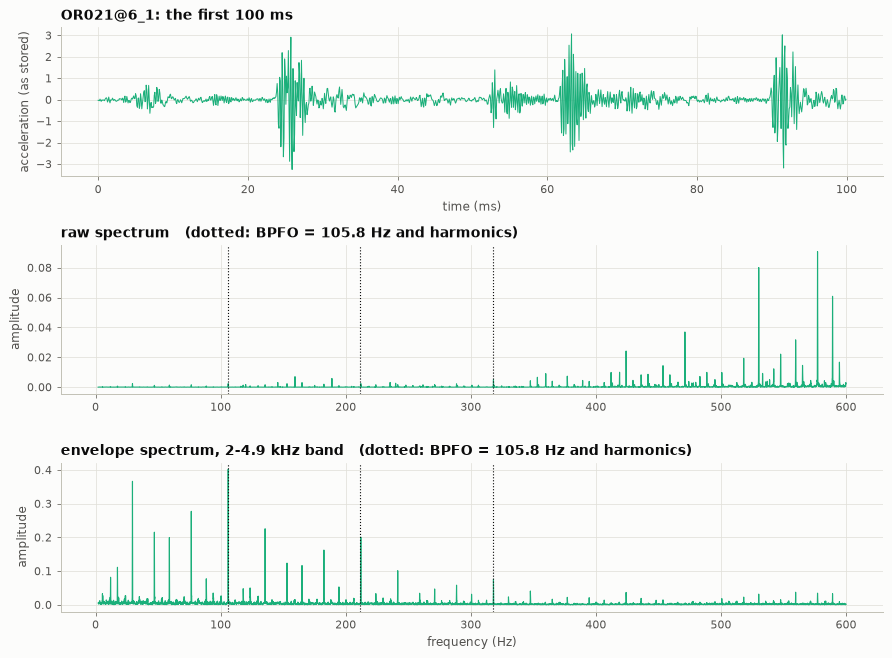

tallest peak below 600 Hz, raw spectrum: 577.2 Hz = 5.46 x BPFO
tallest peak below 600 Hz, envelope spectrum: 106.0 Hz = 1.00 x BPFO


In [5]:
RECORDING = "OR021@6_1"  # try "IR014_1", "B007_1" or "Normal_1"

if HAVE_DATA:
    sig = loader.load(RECORDING, DATA)
    x = dsp.lowpass(sig.x, sig.fs, config.BANDWIDTH_HZ)
    freqs = SKF_6205.frequencies(sig.shaft_hz)
    target = bearing.SIGNATURE.get(sig.recording.fault, "BPFO")
    color = plots.COLOR[sig.recording.fault]
    f, a = dsp.amplitude_spectrum(x, sig.fs)
    fe, ae = dsp.envelope_spectrum(x, sig.fs, config.ENVELOPE_BAND_HZ)

    fig, ax = plt.subplots(3, 1, figsize=(10, 7.4))
    n = int(0.1 * sig.fs)
    ax[0].plot(np.arange(n) / sig.fs * 1000, x[:n], color=color, lw=0.8)
    ax[0].set(title=f"{RECORDING}: the first 100 ms", xlabel="time (ms)", ylabel="acceleration (as stored)")
    for axis, ff, aa, what in ((ax[1], f, a, "raw spectrum"), (ax[2], fe, ae, "envelope spectrum, 2-4.9 kHz band")):
        w = (ff > 2) & (ff < 600)
        axis.plot(ff[w], aa[w], color=color, lw=0.9)
        for k in (1, 2, 3):
            axis.axvline(k * freqs[target], color=plots.INK, ls=":", lw=0.9)
        axis.set(title=f"{what}   (dotted: {target} = {freqs[target]:.1f} Hz and harmonics)", ylabel="amplitude")
    ax[2].set_xlabel("frequency (Hz)")
    fig.tight_layout()
    plt.show()

    for what, ff, aa in (("raw", f, a), ("envelope", fe, ae)):
        w = (ff > 5) & (ff < 600)
        peak = ff[w][np.argmax(aa[w])]
        print(f"tallest peak below 600 Hz, {what} spectrum: {peak:.1f} Hz = {peak / freqs[target]:.2f} x {target}")
else:
    figure("fig3_raw_vs_envelope.png")

Is that one recording typical? Here is the same test on every faulty recording: is the tallest
peak below 600 Hz at the fault frequency, or at one of its first three harmonics (within the project's
±3 % tolerance)?

In [6]:
# is the tallest peak below 600 Hz at the fault frequency, or at one of its first three harmonics?
def tallest_is_fault(ff, aa, fault_hz):
    w = (ff > 5) & (ff < 600)
    peak = ff[w][np.argmax(aa[w])]
    return any(abs(peak - k * fault_hz) <= config.PEAK_TOL * k * fault_hz for k in (1, 2, 3))


if HAVE_DATA:
    rows = []
    for rec in catalog.ALL:
        if not rec.core or rec.fault == "Normal":
            continue
        s = loader.load(rec.name, DATA)
        x = dsp.lowpass(s.x, s.fs, config.BANDWIDTH_HZ)
        fault_hz = SKF_6205.frequencies(s.shaft_hz)[bearing.SIGNATURE[rec.fault]]
        raw = tallest_is_fault(*dsp.amplitude_spectrum(x, s.fs), fault_hz)
        env = tallest_is_fault(*dsp.envelope_spectrum(x, s.fs, config.ENVELOPE_BAND_HZ), fault_hz)
        rows.append({"fault": rec.fault, "raw spectrum": raw, "envelope spectrum": env})
    peaks = pd.DataFrame(rows)
    table = peaks.groupby("fault")[["raw spectrum", "envelope spectrum"]].sum()
    table.insert(0, "recordings", peaks.groupby("fault").size())
    table.loc["all"] = table.sum()
    print("Faulty recordings whose tallest peak below 600 Hz is the fault line:")
    display(table)

Faulty recordings whose tallest peak below 600 Hz is the fault line:


,recordings,raw spectrum,envelope spectrum
fault,,,
B,12,1,0
IR,12,1,11
OR,12,0,8
all,36,2,19


The envelope puts the fault line on top far more often than the raw spectrum does,
but not every time. Ball faults are the weak spot, and the rest of the project keeps running into it.

## 4. The leakage audit: the same model, tested three ways

CWRU has 10 physical bearings. Each was recorded at 4 motor loads, and each recording is cut into
one-second windows. A test is only as honest as the largest unit it keeps apart:

- A. Random windows. Windows from the same recording land in both train and test. This asks:
  *can the model recognise a recording it has already seen?*
- B. Leave one load out. No recording is shared, but every bearing is, at another load. This asks:
  *can it recognise a bearing it has already seen?*
- C. Unseen bearing, unseen load (12 folds). This asks: *can it diagnose a bearing it has never
  seen?* That is the question a plant cares about.

The physics rule learns a single threshold and nothing else, so it can't memorise a recording. Its
score barely moves between protocols. The forest's score drops as soon as the test becomes honest.

,folds,mean_macro_f1,sd_macro_f1,recall_Normal,recall_IR,recall_B,recall_OR
model,,,,,,,
random forest (all features),12,0.732,0.217,1.000,0.775,0.883,0.467
"physics rule, fixed band",12,0.603,0.102,0.829,1.000,0.192,0.683
"physics rule, kurtosis band",12,0.603,0.113,0.781,1.000,0.200,0.708


Forest, protocol C, 10 random seeds: 0.641 to 0.737 (mean 0.702). Post-hoc: this doesn't feed the gate.


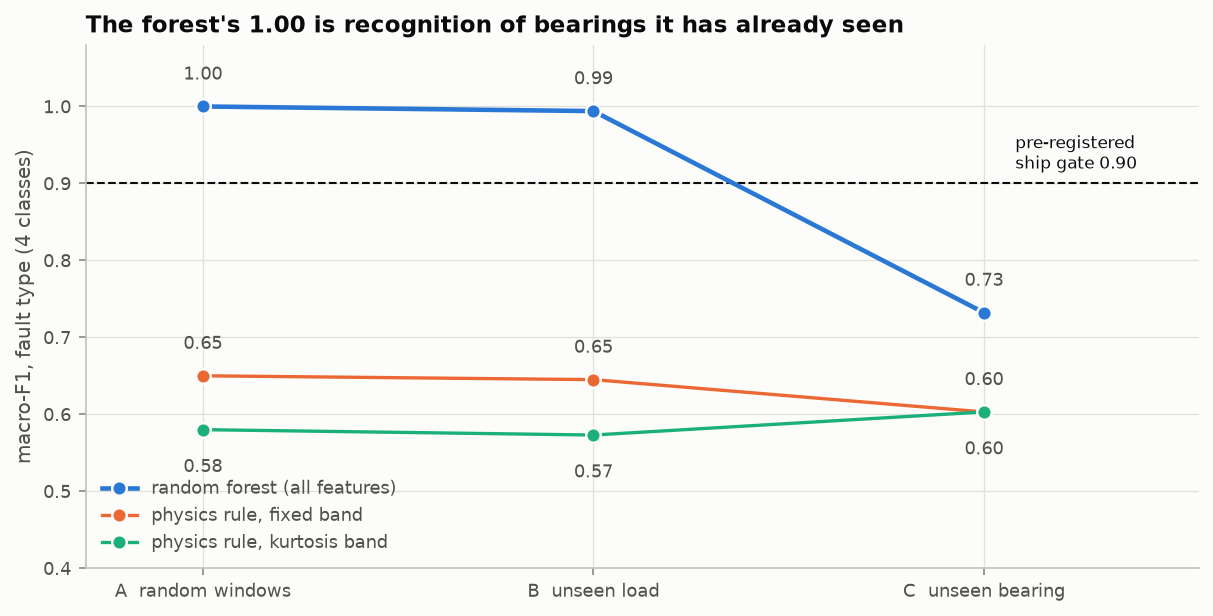

In [7]:
c = audit.query("protocol == 'C_unseen_bearing'").set_index("model")
c.index = c.index.map(plots.MODEL_NAME)
display(c[["folds", "mean_macro_f1", "sd_macro_f1", "recall_Normal", "recall_IR", "recall_B", "recall_OR"]])
seeds = result("seed_sweep_posthoc.json")
print(
    f"Forest, protocol C, 10 random seeds: {seeds['min']:.3f} to {seeds['max']:.3f} (mean {seeds['mean']:.3f})."
    " Post-hoc: this doesn't feed the gate."
)
figure("fig5_split_audit.png")

## 5. Why the forest fails on unseen bearings

Per-bearing results under protocol C show the forest has learned which bearing a signal comes
from, not what fault it has. Faced with a bearing it has never seen, it often falls back on
"ball". The physics rule is the mirror image: it's reliable where a clear fault line exists and
weak on ball faults.

,random forest (all features),"physics rule, fixed band","physics rule, kurtosis band"
bearing,,,
B007,1.000,0.075,0.175
B014,1.000,0.350,0.300
B021,0.650,0.150,0.125
IR007,1.000,1.000,1.000
IR014,0.325,1.000,1.000
IR021,1.000,1.000,1.000
Normal,1.000,0.829,0.781
OR007@6,0.675,1.000,1.000
OR014@6,0.000,0.050,0.125


Forest: windows per bearing (rows) and the class it predicted (columns), protocol C


forest,B,IR,Normal,OR
bearing,,,,
B007,40,0,0,0
B014,40,0,0,0
B021,26,0,0,14
IR007,0,40,0,0
IR014,27,13,0,0
IR021,0,40,0,0
Normal,0,0,105,0
OR007@6,0,13,0,27
OR014@6,40,0,0,0


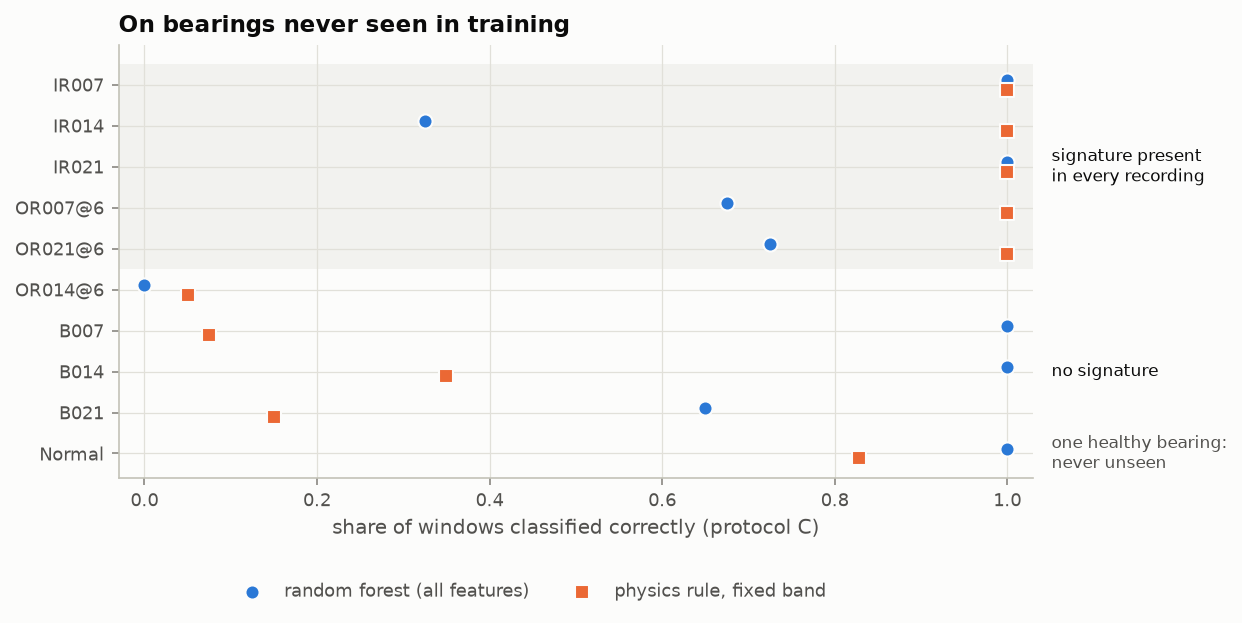

In [8]:
display(result("per_bearing_protocol_C.csv").set_index("bearing").rename(columns=plots.MODEL_NAME))
pred = result("predictions_protocol_C.csv")
print("Forest: windows per bearing (rows) and the class it predicted (columns), protocol C")
display(pd.crosstab(pred.bearing, pred.forest))
figure("fig6_per_bearing.png")

## 6. Industrial evaluation: judged the way a plant judges it

A maintenance team never sees a window-level F1 score. It sees an alarm, then a diagnosis. So the
industrial evaluation, pre-registered in [`docs/industrial-preregistration.md`](../docs/industrial-preregistration.md),
scores every system on:

- one decision per recording, by majority vote of its windows;
- three possible answers: healthy, a named fault, or *undiagnosed*;
- four gate metrics: false-alarm rate (must be 0), detection rate, coverage (how often it names a fault)
  and diagnosis precision (how often the named fault is right).

Plant gate: {'max_false_alarm_rate': 0.0, 'min_detection_rate': 0.9, 'min_diagnosis_precision': 0.95, 'min_coverage': 0.5}.  Ship: False


,false-alarm rate,detection rate,coverage,diagnosis precision,cost per recording,passes plant gate
random forest,0.0,1.0,0.972,0.743,0.583,False
physics rule,0.0,0.917,1.0,0.636,1.375,False
"forest, may abstain",0.0,1.0,0.806,0.724,0.646,False
physics diagnoser,0.25,1.0,0.694,0.679,0.667,False


Physics diagnoser: recordings per bearing (rows) and its decision (columns)


physics_diagnoser,B,Healthy,IR,OR,Undiagnosed
bearing,,,,,
B007,0,0,0,1,3
B014,0,0,0,0,4
B021,0,0,4,0,0
IR007,0,0,3,0,1
IR014,0,0,4,0,0
IR021,0,0,4,0,0
Normal,3,9,0,0,0
OR007@6,0,0,0,4,0
OR014@6,0,0,1,0,3


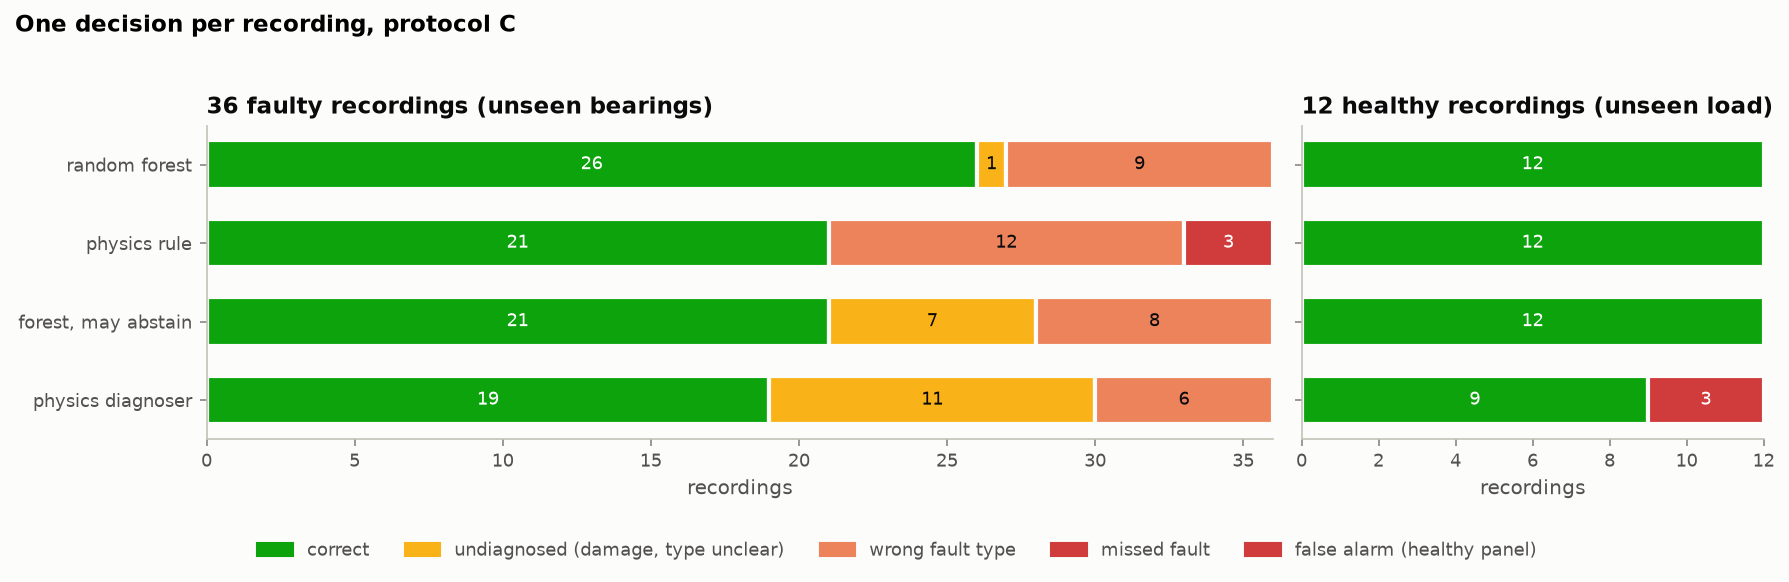

In [9]:
plant = result("industrial_summary.json")
rows = {}
for system, s in plant["systems"].items():
    r = s["recording_level"]
    rows[plots.SYSTEM_NAME[system]] = {
        "false-alarm rate": r["false_alarm_rate"],
        "detection rate": r["detection_rate"],
        "coverage": r["coverage"],
        "diagnosis precision": r["diagnosis_precision"],
        "cost per recording": r["cost_per_recording"],
        "passes plant gate": s["gate"]["passed"],
    }
print(f"Plant gate: {plant['gate_criterion']}.  Ship: {plant['ship']}")
display(pd.DataFrame(rows).T)
decisions = result("industrial_recording_decisions_protocol_C.csv")
print("Physics diagnoser: recordings per bearing (rows) and its decision (columns)")
display(pd.crosstab(decisions.bearing, decisions.physics_diagnoser))
figure("fig9_industrial_outcomes.png")

Both forests catch every faulty recording without a single false alarm, but
they name the wrong fault too often to pass. The physics diagnoser names the fault correctly where a
clear signature exists. It fails in two specific places. B021, a ball fault, looks exactly like an
inner-race fault, sidebands included. And the healthy bearing at 3 HP lies outside the healthy
baseline it learned at 0 to 2 HP. The second failure is why the API below warns when a measurement's
speed is outside its baseline.

## 7. Use it: the public API

`BearingMonitor` packages the physics diagnoser from section 6. You fit it on healthy measurements of
your own machine, covering the speeds you'll run at, and then diagnose new ones. This part only shows
the API; the evaluation itself is section 6.

In [10]:
if HAVE_DATA:

    def measurement(name):
        s = loader.load(name, DATA)
        return s.x, s.fs, s.rpm

    def diagnose_all(monitor, names):
        rows = []
        for name in names:
            d = monitor.diagnose(*measurement(name))
            rows.append(
                {
                    "recording": name,
                    "truth": catalog.get(name).fault,
                    "diagnosis": d.state,
                    "share of windows in alarm": d.alarm_share,
                    "rpm warning": bool(d.warnings),
                }
            )
        return pd.DataFrame(rows).set_index("recording")

    # baseline from the healthy bearing at 0, 2 and 3 HP, then test at 1 HP (inside that range)
    monitor = BearingMonitor().fit_baseline([measurement(f"Normal_{load}") for load in (0, 2, 3)])
    display(
        diagnose_all(
            monitor,
            ["Normal_1"]
            + [f"{b}_1" for b in ("IR007", "IR014", "IR021", "OR007@6", "OR014@6", "OR021@6", "B007", "B014", "B021")],
        )
    )
    print("The whole baseline is this JSON (plus geometry and analysis settings). There is no model file:")
    print(json.dumps(monitor.to_dict()["thresholds"], indent=1))
else:
    print("Needs the recordings: run `bearing-audit fetch` first.")

,truth,diagnosis,share of windows in alarm,rpm warning
recording,,,,
Normal_1,Normal,Healthy,0.2,False
IR007_1,IR,Undiagnosed,1.0,False
IR014_1,IR,IR,1.0,False
IR021_1,IR,IR,1.0,False
OR007@6_1,OR,OR,1.0,False
OR014@6_1,OR,Undiagnosed,1.0,False
OR021@6_1,OR,OR,1.0,False
B007_1,B,Undiagnosed,0.9,False
B014_1,B,Undiagnosed,1.0,False


The whole baseline is this JSON (plus geometry and analysis settings). There is no model file:
{
 "IR": 0.40437181310661485,
 "IR_sb": 0.4983127174540128,
 "OR": 0.5138460425865252,
 "B": 0.5268063684220479,
 "kurtosis": 3.136614564368254,
 "crest": 5.029773777589212,
 "sk_max": 1.5661643665228842
}


The healthy bearing at 3 HP, judged against a baseline from 0 to 2 HP only. That's exactly the
false-alarm case from section 6, and the API now warns about it:

In [11]:
if HAVE_DATA:
    # baseline from 0-2 HP only, then a measurement at 3 HP
    narrow = BearingMonitor().fit_baseline([measurement(f"Normal_{load}") for load in (0, 1, 2)])
    d = narrow.diagnose(*measurement("Normal_3"))
    print(f"Normal_3: {d.state} ({d.alarm_share:.0%} of windows in alarm)")
    print("warning:", *d.warnings)

Normal_3: B (50% of windows in alarm)


## 8. Limitations and next steps

- One healthy bearing. "No false alarms" means none on 12 tests of that single bearing.
- Seeded faults. CWRU's defects were made by electro-discharge machining. Natural spalls grow and
  look different.
- A small sample. Nine faulted bearings. Protocol C's 12 folds reuse the same bearings at
  different loads, so they aren't independent.
- Thresholds don't extrapolate. A healthy baseline is valid only for the operating conditions it
  covers.

Next: a cross-machine test on the Paderborn dataset, and wiring `BearingMonitor` into the
`pdm-service` stream with an MQTT replay.

## 9. Reproduce everything

```bash
make all      # regenerates every result and figure used here (~4 min)
make check    # lint, type check and 90 tests
```

On Linux with `requirements-lock.txt`, `make all` reproduces the committed results byte for byte,
and the figures pixel for pixel. CI checks that on every push. On other platforms the numbers should
agree, but the last digits can differ.